## **Tarea 9**





Usando los datos adjuntados, repetir el análisis del siguiente cuaderno en la medida que se pueda analizar (expliquen porque no en su caso o utilicen alguno de los procedimientos de los otros tutoriales). Expliquen que variables eligen de analizar y por qué.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
#Existen varias formas de visualizar los datos, en este caso usaremos pandas
dataframe = pd.read_excel('S1_Dataset.xlsx')
dataframe.head()

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Sex,Age,BADS-SF,BADS-SF_Activation,BADS-SF_Avoidance,CES-D,WHOQOL-26_Mean total score,WHOQOL-26_Phisical health,WHOQOL-26_Psychological health,WHOQOL-26_Social relationships,WHOQOL-26_Environment,WHOQOL-26_Overall QOL
0,2,20,37,22,3,1,4.500000,4.833333,4.142857,5.000000,4.375,4.5
1,2,18,33,17,2,2,3.307692,3.166667,3.571429,2.666667,3.250,4.0
2,1,19,30,20,8,2,3.500000,3.833333,3.285714,3.666667,3.250,4.0
3,1,19,23,11,6,3,3.346154,3.500000,3.571429,4.000000,2.750,3.5
4,2,18,35,19,2,3,4.461538,4.500000,4.857143,5.000000,3.875,4.5


In [ ]:
#Tambien podemos crear arreglos nosotros
t = np.linspace(-6,6,15)
x = np.sin(t)
y = np.cos(t)
pd.DataFrame({'t':t,'x':x,'y':y})

,t,x,y
0,-6.000000,0.279415,0.960170
1,-5.142857,0.908770,0.417296
2,-4.285714,0.910347,-0.413846
3,-3.428571,0.283056,-0.959103
4,-2.571429,-0.539770,-0.841812
5,-1.714286,-0.989723,-0.142998
6,-0.857143,-0.755975,0.654600
7,0.000000,0.000000,1.000000
8,0.857143,0.755975,0.654600
9,1.714286,0.989723,-0.142998


## Manipulacion de los Datos

In [ ]:
print(f"Tamaño del arreglo{dataframe.shape}")
print(dataframe.columns) #Podemos ver los encabezados de las columnas
print(dataframe['Age']) #Ver los datos de una columna

Tamaño del arreglo(221, 12)
Index(['Sex', 'Age', 'BADS-SF', 'BADS-SF_Activation', 'BADS-SF_Avoidance',
       'CES-D', 'WHOQOL-26_Mean total score', 'WHOQOL-26_Phisical health',
       'WHOQOL-26_Psychological health', 'WHOQOL-26_Social relationships',
       'WHOQOL-26_Environment', 'WHOQOL-26_Overall QOL'],
      dtype='object')
0      20
1      18
2      19
3      19
4      18
       ..
216    19
217    18
218    23
219    18
220    21
Name: Age, Length: 221, dtype: int64


In [ ]:
dataframe["Age"].mean()

19.36651583710407

## Groupby

Aquí agrupamos por edades, primero vemos que existe un dato fuera de lo normal, que es la edad de dos años, posteriormente eliminaremos todo relacionado a ella, Pero aplicando el agrupamiento a las edades y sacando el promedio de los valores relacionados con CES-D que es una evaluacion del 0 al 60 con preguntas que son indicadores de depresion vemos que la edad mas vulnerable es 23 años.

In [ ]:
#Agrupamos las edades
groupby_age = dataframe.groupby('Age')
for Age, value in groupby_age['CES-D']:
  print((Age, value.mean()))

(2, 30.0)
(18, 16.375)
(19, 14.641304347826088)
(20, 14.1)
(21, 15.782608695652174)
(22, 17.818181818181817)
(23, 24.0)
(24, 14.0)
(25, 9.0)


In [ ]:
#Podemos aplicar lo mismo a cada columna
groupby_age.mean()

,Sex,BADS-SF,BADS-SF_Activation,BADS-SF_Avoidance,CES-D,WHOQOL-26_Mean total score,WHOQOL-26_Phisical health,WHOQOL-26_Psychological health,WHOQOL-26_Social relationships,WHOQOL-26_Environment,WHOQOL-26_Overall QOL
Age,,,,,,,,,,,
2,1.000000,11.000000,5.000000,12.000000,30.000000,2.538462,2.000000,3.000000,2.666667,2.750000,1.500000
18,1.520833,24.395833,13.208333,6.812500,16.375000,3.242788,3.166667,3.407738,3.138889,3.195312,3.239583
19,1.478261,22.836957,12.445652,7.608696,14.641304,3.310619,3.114130,3.431677,3.362319,3.330163,3.320652
20,1.725000,25.450000,14.525000,7.075000,14.100000,3.433654,3.366667,3.578571,3.466667,3.378125,3.300000
21,1.608696,24.478261,14.260870,7.782609,15.782609,3.423077,3.181159,3.552795,3.463768,3.532609,3.195652
22,2.000000,19.545455,9.636364,8.090909,17.818182,3.125874,2.909091,3.337662,3.090909,3.193182,2.818182
23,1.750000,18.250000,12.000000,11.750000,24.000000,2.634615,2.250000,2.857143,2.750000,2.687500,2.625000
24,2.000000,17.000000,15.000000,16.000000,14.000000,3.153846,3.000000,2.571429,4.000000,3.625000,2.500000
25,2.000000,26.000000,15.000000,7.000000,9.000000,3.769231,4.333333,3.857143,4.000000,3.375000,3.000000


## *Graficado de Datos*

array([[<Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='BADS-SF', ylabel='Age'>,
        <Axes: xlabel='CES-D', ylabel='Age'>],
       [<Axes: xlabel='Age', ylabel='BADS-SF'>,
        <Axes: xlabel='BADS-SF', ylabel='BADS-SF'>,
        <Axes: xlabel='CES-D', ylabel='BADS-SF'>],
       [<Axes: xlabel='Age', ylabel='CES-D'>,
        <Axes: xlabel='BADS-SF', ylabel='CES-D'>,
        <Axes: xlabel='CES-D', ylabel='CES-D'>]], dtype=object)

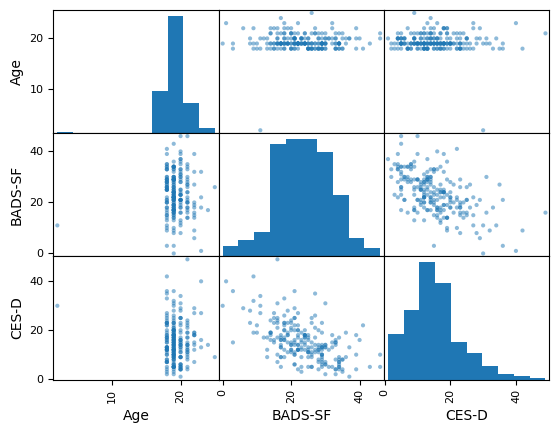

In [ ]:
#Usaremos las erramientas de graficacion de pandas
plotting.scatter_matrix(dataframe[['Age', 'BADS-SF', 'CES-D']])

array([[<Axes: xlabel='WHOQOL-26_Phisical health', ylabel='WHOQOL-26_Phisical health'>,
        <Axes: xlabel='WHOQOL-26_Psychological health', ylabel='WHOQOL-26_Phisical health'>,
        <Axes: xlabel='WHOQOL-26_Social relationships', ylabel='WHOQOL-26_Phisical health'>],
       [<Axes: xlabel='WHOQOL-26_Phisical health', ylabel='WHOQOL-26_Psychological health'>,
        <Axes: xlabel='WHOQOL-26_Psychological health', ylabel='WHOQOL-26_Psychological health'>,
        <Axes: xlabel='WHOQOL-26_Social relationships', ylabel='WHOQOL-26_Psychological health'>],
       [<Axes: xlabel='WHOQOL-26_Phisical health', ylabel='WHOQOL-26_Social relationships'>,
        <Axes: xlabel='WHOQOL-26_Psychological health', ylabel='WHOQOL-26_Social relationships'>,
        <Axes: xlabel='WHOQOL-26_Social relationships', ylabel='WHOQOL-26_Social relationships'>]],
      dtype=object)

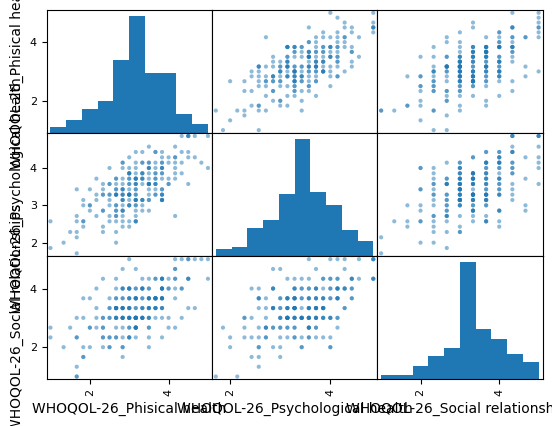

In [ ]:
plotting.scatter_matrix(dataframe[['WHOQOL-26_Phisical health', "WHOQOL-26_Psychological health","WHOQOL-26_Social relationships"]])

## *Prueba de HIpotesis: Comparacion de dos grupos*

In [ ]:
from scipy import stats #Usaremos

> Prueba del valor de la media de una población.

>scipy.stats.ttest_1samp() Comprueba si es probable que la media de la población de los datos sea igual a un valor dado (técnicamente, si las observaciones se extraen de una distribución gaussiana de una media de población dada). Devuelve la estadística T y el valor p.


In [ ]:
stats.ttest_1samp(dataframe['Age'], 19.36)

TtestResult(statistic=0.05578516185247616, pvalue=0.9555635848552362, df=220)

Como el valor de p es muy cercano a 1 podemos afirmar que el valor promedio de edad es muy cercano a 19.36

## Pueba de diferencia entre poblaciones

In [ ]:
#Tenemos la poblacion de hombres y mujeres aplicados al indicador CES-D, veremos si existe una diferencia significativa
m_CESD = dataframe[dataframe['Sex'] == 2]["CES-D"]
h_CESD = dataframe[dataframe['Sex'] == 1]['CES-D']
stats.ttest_ind(m_CESD, h_CESD)

TtestResult(statistic=-1.3080667274651316, pvalue=0.19222198481162514, df=219.0)

El valor de p es muy pequeño esto nos indica que si existe una diferencia significativa en la prueba CES-D aplicada a hombres que a mujeres.

## Pruebas pareadas: mediciones repetidas en los mismos individuos

In [ ]:
#Queremos probar si la parte de salud fisica y salud mental son significativamente diferentes.
stats.ttest_ind(dataframe['WHOQOL-26_Phisical health'], dataframe['WHOQOL-26_Psychological health'])

TtestResult(statistic=-4.544110403208232, pvalue=7.136732212062339e-06, df=440.0)

Vemos a mi sorpesa que sí, existe poca relacion ya que nuestro valor de p es demasiado bajo

In [ ]:
#Usaremos stats.ttest_1samp para comprobar si la media de una muestra es significativamente diferente de la media de una población determinada.
stats.ttest_rel(dataframe['WHOQOL-26_Phisical health'], dataframe['WHOQOL-26_Psychological health'])

TtestResult(statistic=-7.902895144741931, pvalue=1.297876227503606e-13, df=220)

> Las pruebas t suponen errores gaussianos. Podemos utilizar una prueba de rangos con signo de Wilcoxon , que relaja este supuesto:

In [ ]:
stats.wilcoxon(dataframe['WHOQOL-26_Phisical health'], dataframe['WHOQOL-26_Psychological health'])

WilcoxonResult(statistic=5413.5, pvalue=2.6420209139391325e-12)

## Modelos lineales

> Regresion lineal simple

In [ ]:
x = np.linspace(-5, 5, 20)
np.random.seed(1)
# normal distributed noise
y = -5 + 3*x + 4 * np.random.normal(size=x.shape)
# Create a data frame containing all the relevant variables
data = pd.DataFrame({'x': x, 'y': y})

from statsmodels.formula.api import ols
model = ols("y ~ x", data).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Thu, 28 Nov 2024   Prob (F-statistic):           8.56e-08
Time:                        17:52:37   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5335      1.036     -5.342      0.0

Para este caso nosotros igual ya hemos definido un metodo para regresion lineal en nuestra biblioteca personal

## Variables categóricas: comparación de grupos o categorías múltiples

In [ ]:
dataframe = pd.read_excel('S1_Dataset.xlsx', na_values='.')


/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
#Comparamos la edad de hombres y mujeres utilizando un modelo lineal:
models = ols('Age ~ C(Sex)', dataframe).fit()
print(models.summary())

                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     10.86
Date:                Thu, 28 Nov 2024   Prob (F-statistic):            0.00115
Time:                        18:37:14   Log-Likelihood:                -429.69
No. Observations:                 221   AIC:                             863.4
Df Residuals:                     219   BIC:                             870.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      18.9247      0.176    107.435      

## Regresión múltiple: incluye múltiples factores

In [ ]:
#Nos saltaremos el ejemplo que da

In [ ]:
data = pd.read_excel('S1_Dataset.xlsx')
model= ols('Sex ~ Age + Sex', data).fit()
print(model.summary)

<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x7f57b8baa080>>


/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


##  Prueba de hipótesis post hoc: Análisis de varianza (ANOVA)

 Es un método estadístico utilizado para analizar si existen diferencias significativas entre las medias de tres o más grupos independientes. Su objetivo principal es determinar si al menos una de las medias de los grupos difiere significativamente de las demás.

Existe un problema para estas pruebas ya que los puntajes no estan estandarizados, algunos van del 0 al 60 otros tienen otra ponderacion.

In [ ]:
print(model.f_test([0, 1, -1,]))

<F test: F=7.193702667033615e+32, p=0.0, df_denom=218, df_num=1>


## Más visualización: seaborn para exploración estadística

In [ ]:
print(dataframe.head())


   Sex  Age  BADS-SF  BADS-SF_Activation  BADS-SF_Avoidance  CES-D  \
0    2   20       37                  22                  3      1   
1    2   18       33                  17                  2      2   
2    1   19       30                  20                  8      2   
3    1   19       23                  11                  6      3   
4    2   18       35                  19                  2      3   

   WHOQOL-26_Mean total score  WHOQOL-26_Phisical health  \
0                    4.500000                   4.833333   
1                    3.307692                   3.166667   
2                    3.500000                   3.833333   
3                    3.346154                   3.500000   
4                    4.461538                   4.500000   

   WHOQOL-26_Psychological health  WHOQOL-26_Social relationships  \
0                        4.142857                        5.000000   
1                        3.571429                        2.666667   
2          

> En lo personal seaborn tambien es una excelente herramienta para graficar al igual que matplot

## Diagrama de pares: matrices de dispersión

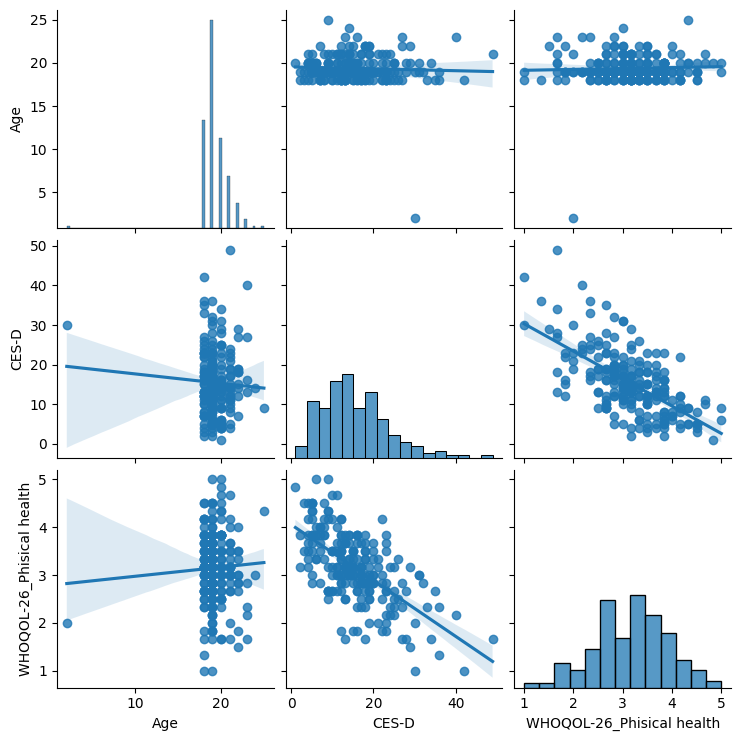

In [ ]:
import seaborn
seaborn.pairplot(data, vars=['Age', 'CES-D', 'WHOQOL-26_Phisical health'],
                 kind='reg')

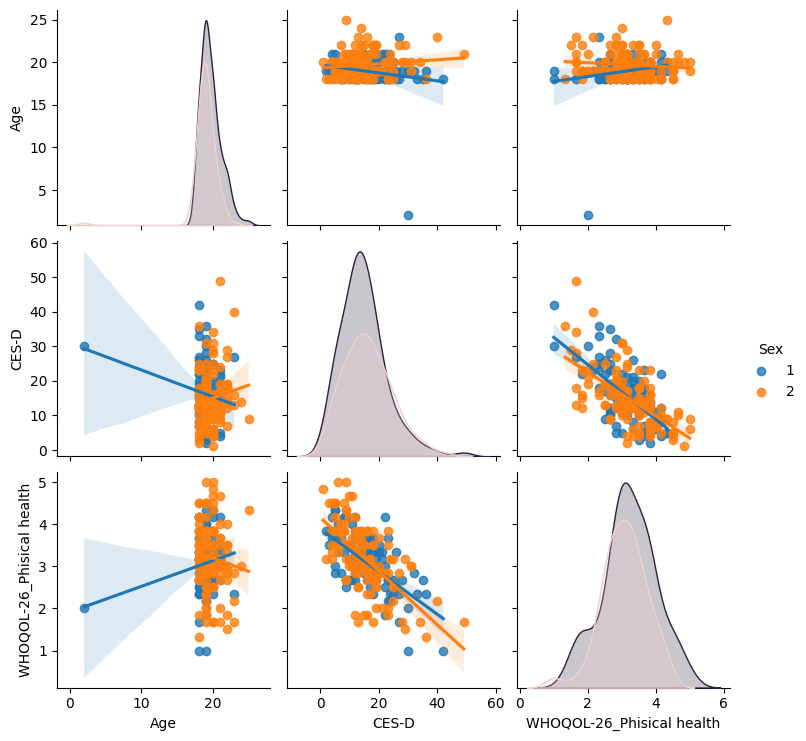

In [ ]:
#Las variables categóricas se pueden representar gráficamente como el tono:
seaborn.pairplot(data, vars=['Age', 'CES-D', 'WHOQOL-26_Phisical health'],
                 kind='reg', hue='Sex')

##  lmplot: representación gráfica de una regresión univariante

Una regresión que captura la relación entre una variable y otra, por ejemplo, el salario y la educación, se puede representar gráficamente utilizando seaborn.lmplot(): En este caso usaremos BADS-SF y el indicadro CES-D

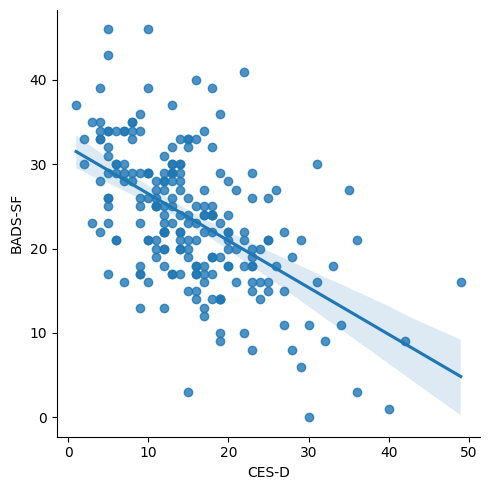

In [ ]:
seaborn.lmplot(y='BADS-SF', x='CES-D', data=data)

Podemos destarcar varias cosas, en la primera grafica podemos ver que las mujere son mas propensas a la depresion por la densidad de puntos, tambien existe indicion de una relacion inversamente proporcional entre el CES-D y BADS-SF por ultimo segun la evalucion de CES-D La edad de mayor riesgo es a los 23 años

## Pruebas de interacciones

El gráfico anterior está compuesto por dos ajustes diferentes. Necesitamos formular un único modelo que pruebe la variación de la pendiente en las dos poblaciones. Esto se hace a través de una 'iteración'.

In [ ]:
import statsmodels.formula.api as sm
result = sm.ols(formula='Sex ~ Age + Sex', data=dataframe).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    Sex   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.549e+32
Date:                Thu, 28 Nov 2024   Prob (F-statistic):               0.00
Time:                        19:49:36   Log-Likelihood:                 7633.4
No. Observations:                 221   AIC:                        -1.526e+04
Df Residuals:                     218   BIC:                        -1.525e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.331e-16   1.84e-16      1.809      0.0